# Business analysis

This notebook reads the reproducible outputs created by `python -m src.pipeline`. It does not contain a separate copy of the cleaning logic or hard-coded analysis results.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / 'data/processed').exists() else Path.cwd().parent
processed = ROOT / 'data/processed'
summary = json.loads((ROOT / 'reports/analysis_summary.json').read_text())
monthly = pd.read_csv(processed / 'monthly_kpis.csv', parse_dates=['month'])
products = pd.read_csv(processed / 'product_performance.csv')
countries = pd.read_csv(processed / 'country_performance.csv')
segments = pd.read_csv(processed / 'customer_segments.csv')
print(json.dumps(summary, indent=2))

/Users/dhirsith/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/gj/wzv5hw490nl3d64v9b12qdhc0000gn/T/matplotlib-r86sy3ze because there was an issue with the default path (/Users/dhirsith/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


{
  "dataset_rows_after_cleaning": 536641,
  "revenue_gbp": 10642110.8,
  "orders_with_positive_quantity": 19960,
  "identified_purchasing_customers": 4338,
  "average_order_value_gbp": 533.17,
  "median_order_net_revenue_gbp": 303.3,
  "repeat_customers_2_or_more_positive_invoices": 2845,
  "repeat_customer_share": 0.6558,
  "top_country_by_net_revenue": "United Kingdom",
  "top_country_revenue_gbp": 9001744.09,
  "top_country_revenue_share": 0.8459,
  "top_stock_code_by_net_revenue": "DOT",
  "top_stock_code_description": "DOTCOM POSTAGE",
  "top_stock_code_revenue_gbp": 206248.77,
  "highest_revenue_month": "2011-11-01",
  "highest_month_revenue_gbp": 1503866.78,
  "lowest_revenue_month": "2011-02-01",
  "lowest_month_revenue_gbp": 522545.56,
  "date_start": "2010-12-01",
  "date_end": "2011-12-09",
  "revenue_definition": "Sum of quantity * unit price for non-cancellation lines with positive unit price; negative quantities on non-cancellation lines reduce revenue as returns.",
  "c

In [2]:
monthly.tail()

,month,revenue_gbp,line_count,order_count,average_order_value_gbp
8,2011-08-01,757841.380,34264,1361,556.826877
9,2011-09-01,1056435.192,48900,1837,575.087203
10,2011-10-01,1151263.730,58537,2040,564.344966
11,2011-11-01,1503866.780,82004,2769,543.108263
12,2011-12-01,637790.330,24833,819,778.742772


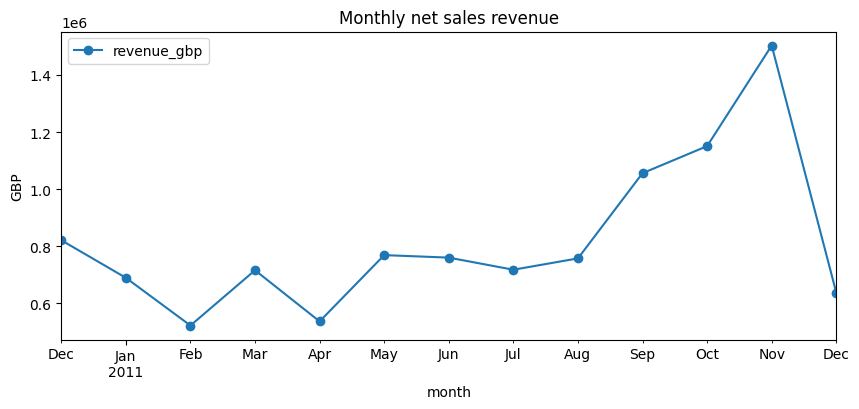

In [3]:
monthly.plot(x='month', y='revenue_gbp', marker='o', figsize=(10, 4), title='Monthly net sales revenue'); plt.ylabel('GBP'); plt.show()

In [4]:
products.head(10)

,product_code,description,revenue_gbp,quantity_net,invoice_count
0,DOT,DOTCOM POSTAGE,206248.77,706,706
1,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
2,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,106236.72,37872,2256
4,47566,PARTY BUNTING,99445.23,18283,1685
5,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
6,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
7,POST,POSTAGE,78101.88,3150,1126
8,M,Manual,77752.82,6985,290
9,23084,RABBIT NIGHT LIGHT,66870.03,30739,994


In [5]:
countries.head(10)

,country,revenue_gbp,invoice_count,customer_count
0,United Kingdom,9001744.094,18019,3920
1,Netherlands,285446.340,94,9
2,EIRE,283140.520,288,3
3,Germany,228678.400,457,94
4,France,209625.370,392,87
5,Australia,138453.810,57,9
6,Spain,61558.560,90,30
7,Switzerland,57067.600,54,21
8,Belgium,41196.340,98,25
9,Sweden,38367.830,36,8


In [6]:
segments.sort_values('revenue_gbp', ascending=False)

,segment,customer_count,revenue_gbp,average_frequency
0,Champions,1299,6467066.421,9.481909
1,At risk,565,996737.721,4.507965
2,Occasional / inactive,1597,818708.582,1.291797
3,Recent customers,731,532744.730,1.504788
4,Loyal,146,71951.440,3.458904
